In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, project_root)
import importlib
import models.pretrained_vgg19 as vgg
importlib.reload(vgg)
import metrics.util_metrics as metrics
importlib.reload(metrics)


In [20]:
#data
batch_size = 16
img_size = (224, 224)
directory = 'C:\\Users\\frank\\OneDrive\\Documents\\vsCodeProjects\\cytology\\data'
seed = 100

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory,
    validation_split=0.4,  
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)


temp_ds = tf.keras.utils.image_dataset_from_directory(
    directory,
    validation_split=0.4,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
temp_ds = temp_ds.cache().prefetch(buffer_size=AUTOTUNE)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

def dataset_to_numpy(ds):
    imgs, labels = [], []
    for x_batch, y_batch in ds.as_numpy_iterator():
        imgs.append(x_batch)
        labels.append(y_batch)
    imgs = np.vstack(imgs)
    labels = np.hstack(labels)
    return imgs, labels

X_train, y_train = dataset_to_numpy(train_ds)
X_val, y_val = dataset_to_numpy(temp_ds)

print(X_train.shape, y_train.shape)

Found 600 files belonging to 3 classes.
Using 360 files for training.
Found 600 files belonging to 3 classes.
Using 240 files for validation.
(360, 224, 224, 3) (360,)


In [21]:

#Build
X_train = preprocess_input(X_train)
X_val = preprocess_input(X_val)
model = vgg.build_vgg19(input_shape=X_train.shape[1:], num_classes=len(np.unique(y_train)))

In [22]:
#Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#optimize
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_control_cnn.h5",
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 841ms/step - accuracy: 0.4832 - loss: 1.3829

23/23 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5389 - loss: 1.1866 - val_accuracy: 0.6625 - val_loss: 1.0810
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8081 - loss: 0.4725

23/23 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8389 - loss: 0.4311 - val_accuracy: 0.7417 - val_loss: 0.7432
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9249 - loss: 0.2435

23/23 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9222 - loss: 0.2498 - val_accuracy: 0.7750 - val_loss: 0.5991
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9276 - loss: 0.2192

23/23 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9167 - loss: 0.2242 - val_accuracy: 0.7833 - val_loss: 0.5116
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9560 - loss: 0.1417

23/23 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9472 - loss: 0.1511 - val_accuracy: 0.8083 - val_loss: 0.4774
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9722 - loss: 0.0946 - val_accuracy: 0.7958 - val_loss: 0.4864
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9833 - loss: 0.0625 - val_accuracy: 0.7625 - val_loss: 0.6267
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9759 - loss: 0.0690

23/23 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9861 - loss: 0.0591 - val_accuracy: 0.8250 - val_loss: 0.4498
Epoch 9/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9861 - loss: 0.0396 - val_accuracy: 0.8167 - val_loss: 0.4780
Epoch 10/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9917 - loss: 0.0337 - val_accuracy: 0.7792 - val_loss: 0.6534
Epoch 11/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9833 - loss: 0.0531 - val_accuracy: 0.8125 - val_loss: 0.4855
Epoch 12/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9861 - loss: 0.0466 - val_accuracy: 0.7792 - val_loss: 0.6231
Epoch 13/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9889 - loss: 0.0395 - val_accuracy: 0.7625 - val_loss: 0.6262


In [24]:
#prediction
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = y_val

8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step


Accuracy: 0.825
F1 Score: 0.8254838046329643
AUC: 0.9489830475343424


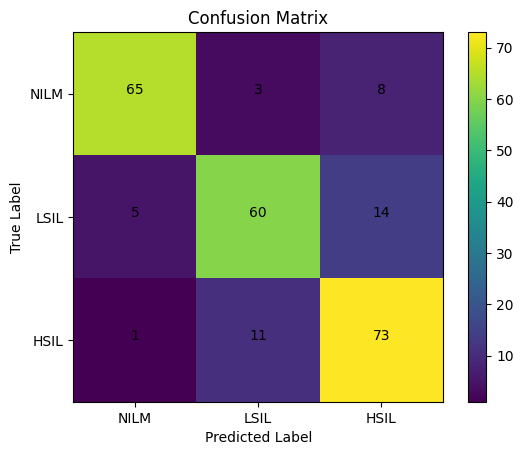

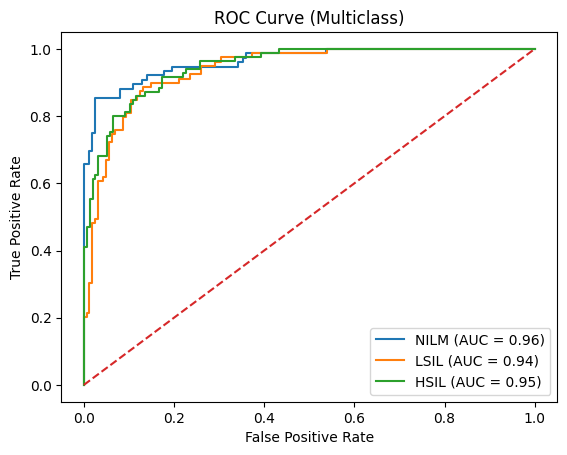

{0: 0.9630937098844672, 1: 0.9368661058259298, 2: 0.9476280834914612}

In [ ]:
#results 
acc = metrics.compute_accuracy(y_true, y_pred)
f1 = metrics.compute_f1(y_true, y_pred)
auc_score = metrics.compute_auc(y_true, y_pred_probs, num_classes=3)

print("Accuracy:", acc)
print("F1 Score:", f1)
print("AUC:", auc_score)

class_names = ["NILM", "LSIL", "HSIL"]

metrics.plot_confusion_matrix(y_true, y_pred, class_names)
metrics.plot_roc_multiclass(y_true, y_pred_probs, 3, class_names)